# 0. Install and Import Libraries

## Install Libraries

In [1]:
# pip install graphviz

In [2]:
!pip install yellowbrick

## Import Libraries

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import seaborn as sbn

In [6]:
import matplotlib.pyplot as plt

In [7]:
from scipy import stats

In [8]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [9]:
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
import sklearn.metrics as sm

In [10]:
from sklearn import metrics

In [11]:
# sklearn for machine learning classification methods
from sklearn import tree
from sklearn import model_selection
from sklearn.model_selection import cross_validate, KFold, cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [12]:
import graphviz

In [13]:
import joblib 

In [14]:
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

In [15]:
from yellowbrick.cluster import SilhouetteVisualizer

# 1. Research Goal  TODO

# 2. Retrieve Data

All data was scraped from bilbasen.dk on: 2022-11-08 at 22:29:38

In [16]:
df_cars = pd.read_csv(r"https://raw.githubusercontent.com/foxdocs/dat-bi/refs/heads/main/Data/cars.csv")

## 2.1 Data Inspection

We will do quick checks to see if the data needs cleaning and to get at better understanding of the domain:

In [17]:
# Check the size of the data-set
df_cars.shape

(2830, 15)

In [18]:
# Check the datatypes to see if further typecasting is needed
df_cars.dtypes

Unnamed: 0      int64
mpg           float64
milage        float64
maketype          str
car_id          int64
region            str
price         float64
make              str
type              str
scrapedate        str
alder           int64
ccm2          float64
doors             str
aldercat          str
navn              str
dtype: object

In [19]:
# Random samples to get a quick overview of the data
df_cars.sample(5)

,Unnamed: 0,mpg,milage,maketype,car_id,region,price,make,type,scrapedate,alder,ccm2,doors,aldercat,navn
885,885,20.8,6.0,"Ford Focus 1,0 EcoBoost mHEV Titanium Style st...",5608059,København,299900.0,Ford,Focus,2022-11-08 22:29:38.772658,0,1000.0,5d,veteran,Region Hovedstaden
968,968,19.6,200000.0,"Ford C-MAX 1,0 SCTi 100 Titanium 5d",5561397,Nordjylland,80000.0,Ford,C-MAX,2022-11-08 22:29:38.772658,9,1000.0,5d,veteran,Region Nordjylland
1304,1304,11.1,209000.0,"Volvo S60 2,4 170 Baltic 4d",5622955,Syd- og Sønderjylland,39900.0,Volvo,S60,2022-11-08 22:29:38.772658,18,2400.0,4d,veteran,Region Syddanmark
857,857,18.5,64000.0,"Toyota Yaris 1,3 VVT-i T2 Touch 5d",5628705,Syd- og Vestsjælland,69800.0,Toyota,Yaris,2022-11-08 22:29:38.772658,10,1300.0,5d,veteran,Region Sjælland
712,712,16.1,127000.0,"Ford Kuga 1,5 SCTi 150 Titanium 5d",5609257,Fyn,169900.0,Ford,Kuga,2022-11-08 22:29:38.772658,7,1500.0,5d,veteran,Region Syddanmark


In [20]:
# We will check how many unique values there is for each column, so we can determine is we want to keep the column
df_cars.nunique()

Unnamed: 0    2830
mpg            126
milage         646
maketype       855
car_id        2830
region           9
price          758
make             3
type            73
scrapedate       1
alder           65
ccm2            30
doors            4
aldercat         1
navn             5
dtype: int64

In [21]:
# Check to see how many different cars there is of each make
df_cars['make'].value_counts()

make
Ford      1582
Toyota     990
Volvo      258
Name: count, dtype: int64

In [22]:
# Check descrivtive values.
df_cars.describe()

,Unnamed: 0,mpg,milage,car_id,price,alder,ccm2
count,2830.000000,2791.000000,2830.000000,2.830000e+03,2830.000000,2830.000000,2822.000000
mean,1414.500000,19.818631,100177.604240,5.543292e+06,145862.946643,7.949823,1348.157335
std,817.094956,4.713819,77699.608577,1.540043e+05,109811.551112,8.636423,554.564514
min,0.000000,6.900000,0.000000,3.057822e+06,2799.000000,-1.000000,1000.000000
25%,707.250000,16.100000,41000.000000,5.523972e+06,69800.000000,3.000000,1000.000000
50%,1414.500000,20.800000,87750.000000,5.583950e+06,119900.000000,6.000000,1000.000000
75%,2121.750000,23.300000,143000.000000,5.612806e+06,199500.000000,10.000000,1500.000000
max,2829.000000,39.300000,510300.000000,5.631020e+06,999995.000000,92.000000,5800.000000


In [23]:
# Check to see if there are NaN's
df_cars.isna().sum()

Unnamed: 0     0
mpg           39
milage         0
maketype       0
car_id         0
region         9
price          0
make           0
type           0
scrapedate     0
alder          0
ccm2           8
doors          0
aldercat       0
navn           9
dtype: int64

In [24]:
# Check if there is duplicated rows
df_cars.duplicated().sum()

np.int64(0)

### Data Inspection Conclusion
From the above operations we have made the following observations:
* The 'mpg' column seems to contain the cars fuel ecomnomy in km/l and will therefore be renamed
* 'region' vs 'navn'. Looking at Bilbasen.dk they seem to have their own division of Denmark in what is the column 'region', whereas 'navn' follows the offical regions of Denmark. They will therefore be renamed to be more fitting.
* The column 'doors' is a string but we will transform it to be an int
* Maketype kolonnen skal der trækkes information ud af of så fjern den, da den ellers bare gentager data
* Drop 'unnamed id' column as it is redundant
* Drop 'scracpedata' as it only contains one unique value
* Drop 'region' from 'navn' column
* 'milage' column will be renamed to odometer
* All column names will be translated to english
* 'aldercat' only has one unique value and we will therefor remake the age categories
* Some cars have negative ages

* We can see that there are 4 columns with missing data that we will have to handle,:
- Mpg
- Region
- ccm2
- navn

* The data only consists of cars for 3 automakers, so our findings will not be representative for all cars


# 3. Data Preparation

In [25]:
df_clean = df_cars.copy()

In [26]:
# Drop 'scrapedate' column as it only contains one unique value
# Drop 'Unnamed: 0' column as we already have 'car_id' and a built in id
df_clean = df_clean.drop(columns = ['scrapedate', 'Unnamed: 0'])

In [27]:
# Rename colums to more fitting names and keeping everything in english
df_clean = df_clean.rename(columns = {'mpg': 'km/l', 'milage': 'odometer', 'region': 'countrypart', 'type': 'model', 'alder': 'age', 'alder': 'age', 'aldercat': 'age_cat', 'navn': 'region'})

In [28]:
# Remove the "d" from the 'doors' column and convert to an int
df_clean['doors'] = df_clean['doors'].str.replace('d', '').astype(int)

In [29]:
# Remove the "Region" in the 'region' column as it is unnecessary repeating data 
df_clean['region'] = df_clean['region'].str.replace('Region', '')

#### Extraction of data from 'maketype'

In [30]:
# All outcommented until the extraxtion is fixed :)
# Extract the 'edition' part of the car (the part between the engine size and door count in 'maketype')
#df_clean['edition'] = df_clean['maketype'].str.extract('\d[.,]\d\s+(.*?)\s+\d+d')
#df_clean['edition'] = df_clean['maketype'].str.extract(r'\d[.,]\d[i]?\s+(.*?)\s+\d+d')

In [31]:
# Check the cars with NaN for 'edition'
#df_nan_edition = df_clean[df_clean['edition'].isna()]
#df_nan_edition.head(10)

#### Fix age_cat column

In [32]:
# Fix 'age_cat' as it currently only has one unique value
labels_age_cat = ['New', 'Lightly Used', 'Moderately Used', 'Old', 'Veteran']

# -np.inf as 3 cars have an age of -1, those cars will be categorised as "New"
bins_age_cat = [-np.inf, 3, 8, 15, 35, np.inf]

df_clean['age_cat'] = pd.cut(df_clean['age'], bins = bins_age_cat, labels = labels_age_cat, include_lowest = True)

#### Fix negative age

In [33]:
# We will check which cars have a negative age to dertermine what to do
df_clean.loc[df_clean['age'] < 0].head()

,km/l,odometer,maketype,car_id,countrypart,price,make,model,age,ccm2,doors,age_cat,region
105,22.0,0.0,"Ford Focus 1,0 EcoBoost mHEV Titanium X stc. D...",5616252,Vestjylland,369900.0,Ford,Focus,-1,1000.0,5,New,Syddanmark
181,22.0,0.0,"Ford Focus 1,0 EcoBoost mHEV Titanium stc. 5d",5615552,Nordsjælland,4995.0,Ford,Focus,-1,1000.0,5,New,Sjælland
588,23.3,3000.0,"Ford Focus 1,0 EcoBoost mHEV Titanium 5d",5581761,Vestjylland,289500.0,Ford,Focus,-1,1000.0,5,New,Syddanmark


In [34]:
# All cars with a negative age will have it replaced with 0, as they appear to be new cars
df_clean.loc[df_clean['age'] < 0, 'age'] = 0

### Handling Missing values

#### Fix NaN's for 'km/l'

In [35]:
# First we will investigate the rows with the missing values.
# We can see that all the cars with missing km/l are all very old and have different engine sizes
df_clean[df_clean['km/l'].isna()].head(5)

,km/l,odometer,maketype,car_id,countrypart,price,make,model,age,ccm2,doors,age_cat,region
2,NaN,51000.0,"Ford Mustang 4,7 V8 289cui. 2d",5506605,København,245000.0,Ford,Mustang,57,4700.0,2,Veteran,Hovedstaden
396,NaN,1.0,Ford A Tudor Sedan 2d,5408194,Syd- og Sønderjylland,129800.0,Ford,A,92,NaN,2,Veteran,Syddanmark
415,NaN,90000.0,"Ford Mustang 4,6 GT Coupé 2d",4332937,Syd- og Sønderjylland,279900.0,Ford,Mustang,18,4600.0,2,Old,Syddanmark
649,NaN,86000.0,"Ford Mustang 4,0 V6 2d",5512033,Østjylland,209800.0,Ford,Mustang,17,4000.0,2,Old,Midtjylland
1508,NaN,0.0,"Toyota Corolla 1,6 GT 3d",5616096,Syd- og Sønderjylland,70000.0,Toyota,Corolla,37,1600.0,3,Veteran,Syddanmark


In [36]:
# We will replace the NaN's with the average km/l for each engine size, instead of giving the same average km/l for all cars
kml_mean_by_ccm2 = df_clean.groupby(by='ccm2')['km/l'].mean()

# Fill in the missing values for km/l by engine size
df_clean['km/l'] = df_clean['km/l'].fillna(df_clean['ccm2'].map(kml_mean_by_ccm2))

# Check if there is still missing values:
print(kml_mean_by_ccm2)
print(df_clean['km/l'].isna().sum())

ccm2
1000.0    23.211698
1100.0    21.514286
1200.0    20.304425
1250.0    17.996429
1300.0    17.983516
1400.0    15.729730
1500.0    17.888102
1600.0    15.197802
1700.0    13.033333
1800.0    14.400000
1900.0    11.400000
2000.0    14.141722
2100.0          NaN
2300.0    10.635714
2400.0    10.939655
2500.0    10.308108
2800.0    10.300000
2900.0     9.325000
3000.0     9.841667
3300.0          NaN
3700.0    10.175000
3900.0     8.800000
4000.0     9.266667
4600.0          NaN
4700.0     8.775000
4800.0     9.100000
4900.0     9.200000
5000.0     9.961538
5400.0     8.000000
5800.0          NaN
Name: km/l, dtype: float64
7


In [37]:
# We can see that some of the engine sizes still do not have a corresponding km/l,
# so they will get filled with the average km/l of all cars as it is only 7 cars
kml_mean = df_clean['km/l'].mean()

# Fill in the remaing NaN's with the average km/l of all cars
df_clean['km/l'] = df_clean['km/l'].fillna(kml_mean)

#### Fix NaN's for 'contrypart' and 'region' :

In [38]:
# First we will investigate the rows with the missing values
df_clean[df_clean['countrypart'].isna()]

,km/l,odometer,maketype,car_id,countrypart,price,make,model,age,ccm2,doors,age_cat,region
285,26.200000,12000.0,"Toyota Aygo 1,0 VVT-i x-sky x-shift 5d",5614314,NaN,134900.0,Toyota,Aygo,3,1000.0,5,New,NaN
345,26.200000,12000.0,"Toyota Aygo 1,0 VVT-i x-press x-shift 5d",5620191,NaN,134900.0,Toyota,Aygo,2,1000.0,5,New,NaN
457,19.600000,111000.0,"Ford Focus 1,0 SCTi 125 Titanium stc. ECO 5d",5598625,NaN,104900.0,Ford,Focus,9,1000.0,5,Moderately Used,NaN
1599,15.197802,85700.0,"Toyota Celica 1,6 ST 2d",5609961,NaN,73800.0,Toyota,Celica,48,1600.0,2,Veteran,NaN
1676,8.700000,108000.0,"Ford Mustang 5,0 GT aut. 2d",5606646,NaN,192400.0,Ford,Mustang,8,5000.0,2,Lightly Used,NaN
2253,14.400000,97250.0,"Volvo P1800 1,8 2d",5553055,NaN,299000.0,Volvo,P1800,61,1800.0,2,Veteran,NaN
2421,15.197802,83930.0,"Volvo PV444 1,6 B16 2d",5511558,NaN,61800.0,Volvo,PV444,66,1600.0,2,Veteran,NaN
2647,15.197802,90000.0,"Ford Capri 1,6 L 3d",5426757,NaN,139900.0,Ford,Capri,46,1600.0,3,Veteran,NaN
2764,14.400000,50000.0,"Volvo Amazon 1,8 121 2d",5260022,NaN,137000.0,Volvo,Amazon,54,1800.0,2,Veteran,NaN


In [39]:
# As it is only 9 rows with missing countrypart and region, we will fill it in with "unknown", to keep the rest of the data
df_clean['countrypart'] = df_clean['countrypart'].fillna('Unknown')
df_clean['region'] = df_clean['region'].fillna('Unknown')

#### Fix NaN's for 'ccm2

In [40]:
df_clean[df_clean['ccm2'].isna()]

,km/l,odometer,maketype,car_id,countrypart,price,make,model,age,ccm2,doors,age_cat,region
396,19.747025,1.0,Ford A Tudor Sedan 2d,5408194,Syd- og Sønderjylland,129800.0,Ford,A,92,NaN,2,Veteran,Syddanmark
707,7.800000,278419.0,"Volvo XC90 2,9i T6 aut. AWD 7prs 5d",5619076,Syd- og Vestsjælland,69900.0,Volvo,XC90,19,NaN,5,Old,Sjælland
2029,12.500000,83000.0,"Ford Escort 1,6i CLX 5d",5580543,Syd- og Vestsjælland,55000.0,Ford,Escort,26,NaN,5,Old,Sjælland
2288,12.400000,0.0,"Ford Mercury Capri 1,6i 16V Cabriolet 2d",5546238,Syd- og Sønderjylland,69800.0,Ford,Mercury,30,NaN,2,Old,Syddanmark
2355,11.600000,197000.0,"Volvo V50 2,4i Summum 5d",5630192,Syd- og Vestsjælland,39990.0,Volvo,V50,17,NaN,5,Old,Sjælland
2492,19.747025,179000.0,"Toyota Supra 2,8i GT aut. 3d",5494741,Østjylland,199900.0,Toyota,Supra,38,NaN,3,Veteran,Midtjylland
2716,19.747025,5000.0,Ford A Tudor Sedan 2d,5358915,Syd- og Sønderjylland,129800.0,Ford,A,92,NaN,2,Veteran,Syddanmark
2740,14.500000,65000.0,"Ford Escort 1,3i CL 3d",5316337,Østjylland,34900.0,Ford,Escort,28,NaN,3,Old,Midtjylland


In [41]:
# We can see some of the engine sizes have not been extracted because the are named with a letter directly after the engine size
# And 2 cars do not have an engine size in the 'maketype' column. Those cars we will drop
df_clean = df_clean.dropna(subset=['ccm2'])

extracted_liters = df_clean['maketype'].str.extract(r'(\d[.,]\d)').replace(',', '.', regex=True).astype(float)

# convert to ccm2
extracted_ccm = extracted_liters[0] * 1000

# Replace the NaN's
df_clean['ccm2'] = df_clean['ccm2'].fillna(extracted_ccm)

In [42]:
# Now we will drop the maketype column as we have extraced everything from it and saved in new columns (make, model and edition)
# df_clean = df_clean.drop(columns = ['maketype'])  # Outcommented until all info is extracted from 'maketype'

### Conclusion

In [43]:
# Check the cleaned data
df_clean.head(3)

,km/l,odometer,maketype,car_id,countrypart,price,make,model,age,ccm2,doors,age_cat,region
0,21.600,18000.0,"Toyota Yaris 1,5 VVT-iE T3 Smart 5d",5559177,København,169900.0,Toyota,Yaris,3,1500.0,5,New,Hovedstaden
1,20.400,254000.0,"Ford Ka 1,2 Trend 3d",4367512,Nordjylland,34900.0,Ford,Ka,11,1200.0,3,Moderately Used,Nordjylland
2,8.775,51000.0,"Ford Mustang 4,7 V8 289cui. 2d",5506605,København,245000.0,Ford,Mustang,57,4700.0,2,Veteran,Hovedstaden


In [44]:
# Check if there is still missing data
df_clean.isna().sum()

km/l           0
odometer       0
maketype       0
car_id         0
countrypart    0
price          0
make           0
model          0
age            0
ccm2           0
doors          0
age_cat        0
region         0
dtype: int64

### Remove Outliers

#### Price vs Age for veteran cars and modern cars
We want to see if the age of both veteran and modern cars have different correlations with the price

In [45]:
df_clean_veterans = df_clean[df_clean['age'] >= 35].copy()

df_clean_modern = df_clean[df_clean['age'] < 35].copy()

print(f"Number of veteran cars: {len(df_clean_veterans)}")
print(f"Number of modern cars: {len(df_clean_modern)}")

Number of veteran cars: 54
Number of modern cars: 2768


Text(0.5, 1.0, 'Price depreciation for modern cars vs price correlation for veteran cars')

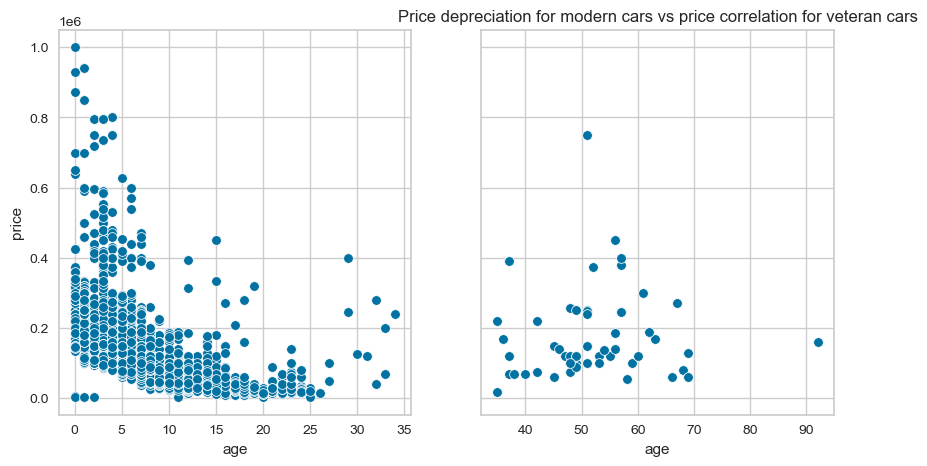

In [46]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize=(10, 5), sharey = True)

# Modern cars
sbn.scatterplot( data = df_clean_modern, ax = axes[0], x = 'age', y = 'price')

# Veteran cars
sbn.scatterplot( data = df_clean_veterans, ax = axes[1], x = 'age', y = 'price')

plt.title("Price depreciation for modern cars vs price correlation for veteran cars")

In the plots above we can see that for modern cars there is a negative correlation with the age of a car and for veteran cars their seems to be no correlation or perhaps a slight positive correlation with the age, which could be because some older cars are considered collectibles. 

We will therefore remove the "veteran" cars as they are a segment of their own and we will focus on the "everyday" cars 

#### Remove outliers by IQR-method


In [47]:
# Function to remove outliers
def remove_outliers(df, column: str, factor: float):
    # Calculate interquartile range
    Q1 = df[column].quantile(.25)
    Q3 = df[column].quantile(.75)
    IQR = Q3 - Q1

    # Set the cutoff borders defining what is an outlier
    lower_border = Q1 - factor * IQR
    upper_border = Q3 + factor * IQR

    # Keep only the rows within the borders, thereby removing the outliers
    df_without_outliers = df[(df[column] >= lower_border) & (df[column] <= upper_border)]
    
    return df_without_outliers

In [48]:
df_clean_modern.describe()

,km/l,odometer,car_id,price,age,ccm2,doors
count,2768.000000,2768.000000,2.768000e+03,2768.000000,2768.000000,2768.000000,2768.000000
mean,19.888420,100471.744942,5.550532e+06,145432.950506,6.991329,1328.070809,4.788656
std,4.670543,77631.520680,1.242048e+05,109474.845496,5.427240,517.352975,0.610522
min,6.900000,0.000000,3.057822e+06,2799.000000,0.000000,1000.000000,2.000000
25%,16.100000,41000.000000,5.528234e+06,69800.000000,3.000000,1000.000000,5.000000
50%,20.800000,88000.000000,5.585066e+06,119900.000000,6.000000,1000.000000,5.000000
75%,23.300000,143000.000000,5.613234e+06,199500.000000,9.000000,1500.000000,5.000000
max,39.300000,510300.000000,5.631020e+06,999995.000000,34.000000,5400.000000,5.000000


In [49]:
# Check the skewness before removing outliers
dfskewed = pd.DataFrame({
    'Modern cars skewness': df_clean_modern.skew(numeric_only=True),
})

dfskewed.style.background_gradient(cmap='Reds')

,Modern cars skewness
km/l,-0.295615
odometer,1.114661
car_id,-7.477720
price,2.059740
age,1.166245
ccm2,3.103747
doors,-2.890827


In [50]:
df_without_outliers = df_clean_modern.copy()

for column in ['price', 'km/l', 'odometer', 'age']:
    df_without_outliers = remove_outliers(df_without_outliers, column, 1.5)

In [51]:
dfskewed2 = pd.DataFrame({
    'Modern cars Original': df_clean_modern.skew(numeric_only=True),
    'Modern cars Without outliers': df_without_outliers.skew(numeric_only=True)
})

dfskewed2.style.background_gradient(cmap='Reds')

,Modern cars Original,Modern cars Without outliers
km/l,-0.295615,-0.358338
odometer,1.114661,0.632085
car_id,-7.477720,-8.115360
price,2.059740,0.598383
age,1.166245,0.680333
ccm2,3.103747,2.859967
doors,-2.890827,-3.190339


We can see that after cleaning we are now much closer to a normal distribution for most attributes. 'ccm2' has not gone through outlier removal as we consider it a categorical value, given that in the car industry enginge sizes follows a certain range of sizes and is therefore not a continuous value.

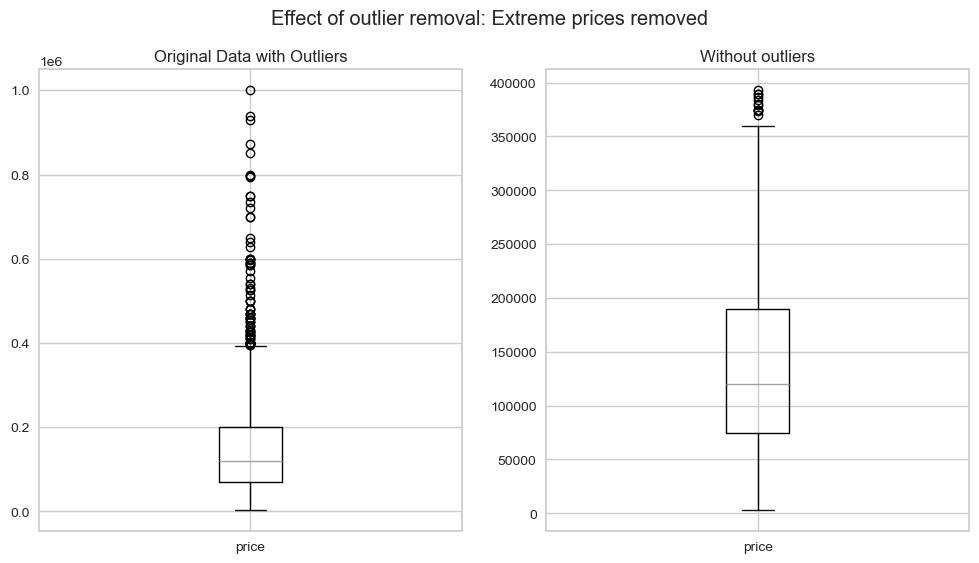

In [52]:
# Boxplots of before and after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Effect of outlier removal: Extreme prices removed')

df_clean_modern.boxplot(column=['price'], ax=axes[0])
axes[0].set_title('Original Data with Outliers')

df_without_outliers.boxplot(column=['price'], ax=axes[1])
axes[1].set_title('Without outliers')

plt.show()

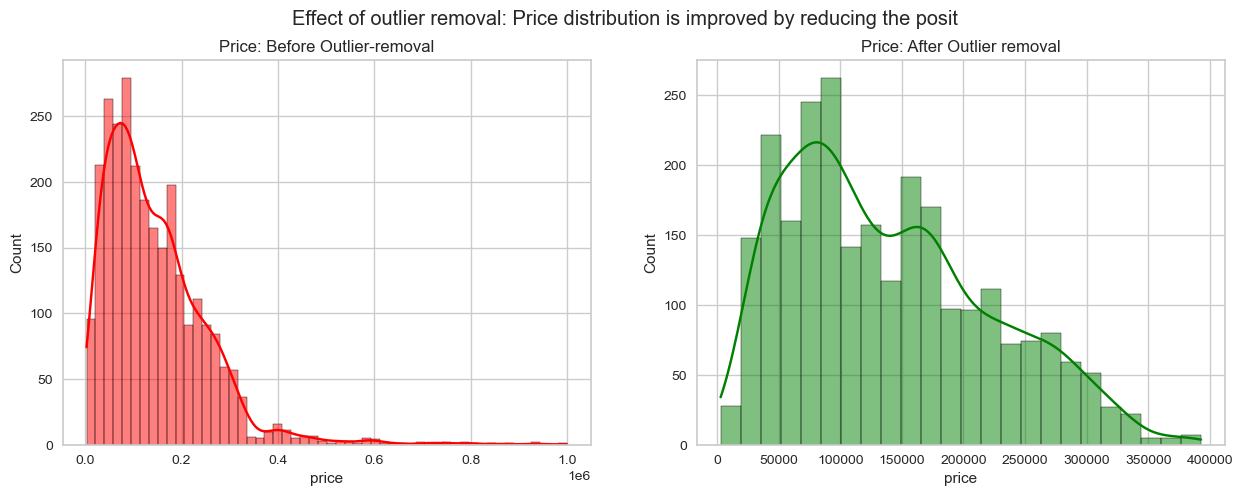

In [53]:
# Plots showing the effect of the outlier removal on the price
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sbn.histplot(df_clean_modern['price'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Price: Before Outlier-removal')

sbn.histplot(df_without_outliers['price'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Price: After Outlier removal')

fig.suptitle("Effect of outlier removal: Price distribution is improved by reducing the posit")


plt.show()

### Normalisation and scaling

In [54]:
features_to_scale = ['odometer', 'age', 'ccm2', 'km/l']

scaler = MinMaxScaler()
df_scaled = df_without_outliers.copy()

df_scaled[features_to_scale] = scaler.fit_transform(df_without_outliers[features_to_scale])

# 4. Data Exploration

array([[<Axes: title={'center': 'km/l'}>,
        <Axes: title={'center': 'odometer'}>,
        <Axes: title={'center': 'car_id'}>],
       [<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'ccm2'}>],
       [<Axes: title={'center': 'doors'}>, <Axes: >, <Axes: >]],
      dtype=object)

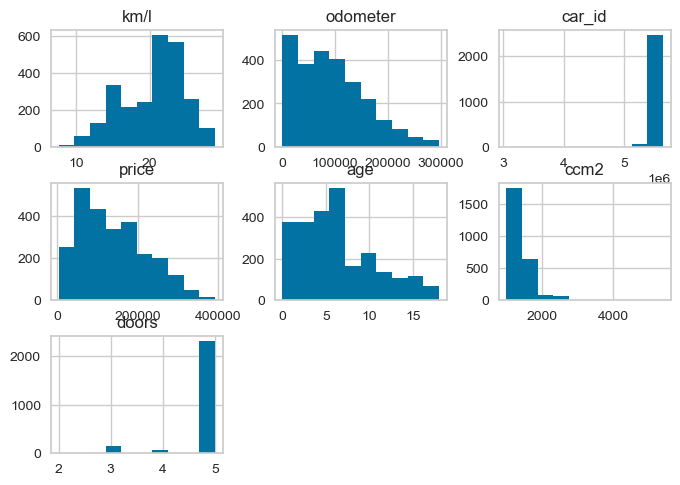

In [55]:
# Quick overview of the distrubutions
df_without_outliers.hist()

We can see km/l, odometer, price and age have somewhat normal distributions and all but km/l have a right skew

In [137]:
# Check the most popular car make and model
df_without_outliers.groupby(['make', 'model']).size().nlargest(5)

In [144]:
# Check the stats of the most popular car
fiesta_data = df_without_outliers[(df_without_outliers['make'] == 'Ford') & (df_without_outliers['model'] == 'Fiesta')]

print(fiesta_data.mean(numeric_only=True))

km/l        2.237846e+01
odometer    8.119539e+04
car_id      5.560398e+06
price       1.307243e+05
age         5.256917e+00
ccm2        1.051383e+03
doors       4.837945e+00
dtype: float64


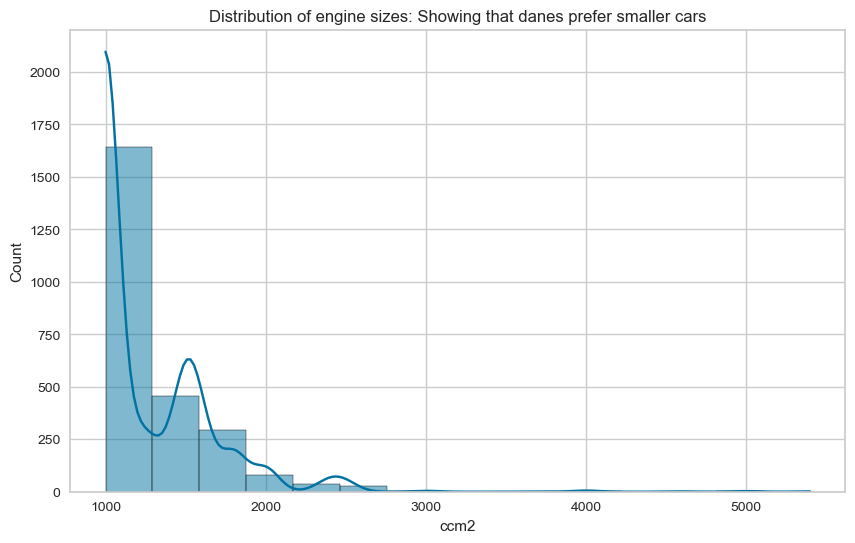

In [155]:
# Histogram of ccm2 
plt.figure(figsize=(10, 6))
sbn.histplot(df_without_outliers['ccm2'], bins=15, kde=True)


plt.title('Distribution of engine sizes: Showing that danes prefer smaller cars')

plt.show()

In [163]:
# Check to see mean price grouped by region
region_stats = df_without_outliers.groupby('region')['price'].mean().sort_values()

print(region_stats)

region
 Sjælland       130677.110930
 Nordjylland    131382.869198
 Midtjylland    134465.295673
 Hovedstaden    140972.671429
Unknown         141775.000000
 Syddanmark     147175.080607
Name: price, dtype: float64


In [ ]:
We can see that Syddanmark has the highest mean of car prices

In [164]:
# Plot to see how det cars are distributed across the regions
regs = df_without_outliers.groupby('region').size()
regs

region
 Hovedstaden    420
 Midtjylland    416
 Nordjylland    237
 Sjælland       613
 Syddanmark     856
Unknown           4
dtype: int64

<Axes: >

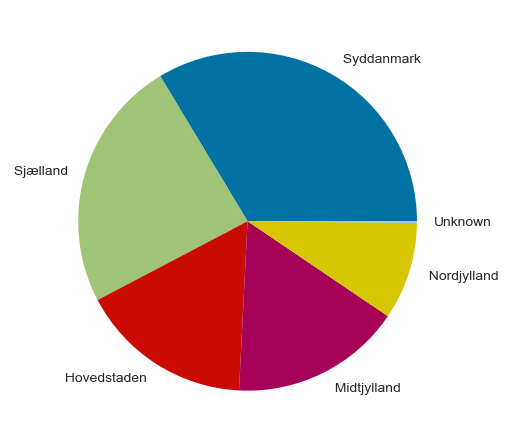

In [57]:
regs.sort_values(ascending=False).plot.pie()

We can see the data is quite evenly distributed across the country.

In [58]:
# Explore the car brand
make = df_without_outliers.groupby('make').size()
make

make
Ford      1494
Toyota     923
Volvo      129
dtype: int64

<Axes: >

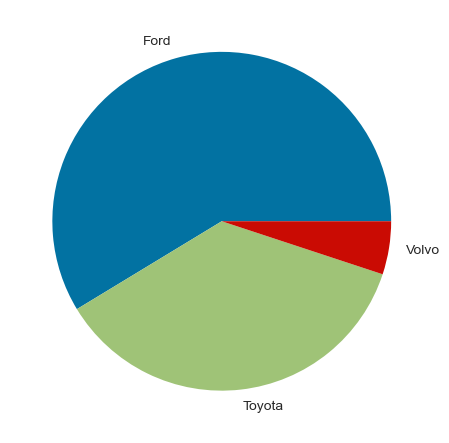

In [59]:
make.sort_values(ascending=False).plot.pie()

We can see that the data consist mainly of Fords and Toyotas and is therefore not representive for the whole car sale industry in Denmark

## Correlations

In [60]:
corr = df_scaled.corr(method='pearson', numeric_only=True)

<Axes: >

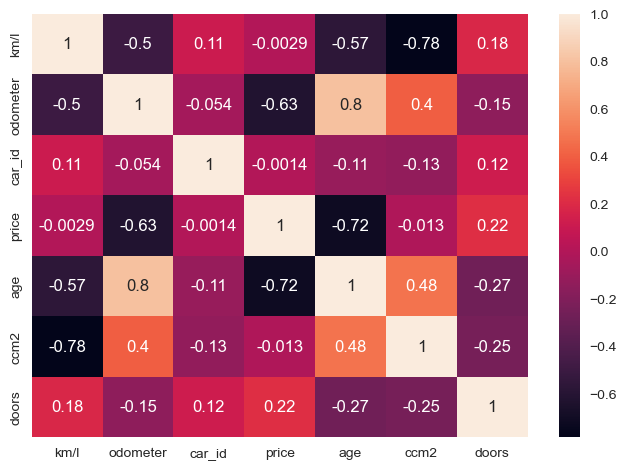

In [61]:
sbn.heatmap(corr, annot=True)

From the heatmap we can see the that age and odometer have the biggest impact on price with a negative correlation

Text(0.5, 1.0, "Price vs. Km's driven: Negative correlation")

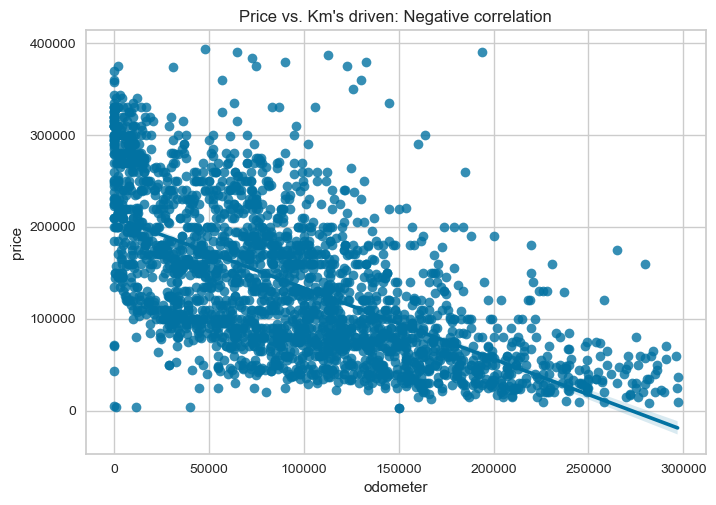

In [62]:
# Scatterplot to see the price vs km's driven
sbn.regplot(data=df_without_outliers, x='odometer', y='price')
plt.title("Price vs. Km's driven: Negative correlation")

## Descriptive Statistics

In [63]:
# Descriptive stats of numeric columns only
df_without_outliers[['price', 'odometer', 'age', 'ccm2', 'km/l']].describe()


,price,odometer,age,ccm2,km/l
count,2546.000000,2546.000000,2546.000000,2546.000000,2546.000000
mean,138624.455224,93280.837392,6.361351,1254.988217,20.462692
std,82016.645154,66491.544553,4.443735,402.554051,4.319785
min,2799.000000,0.000000,0.000000,1000.000000,7.600000
25%,74800.000000,39000.000000,3.000000,1000.000000,16.900000
50%,119999.500000,86000.000000,6.000000,1000.000000,21.200000
75%,189900.000000,136000.000000,9.000000,1500.000000,23.300000
max,392900.000000,297000.000000,18.000000,5400.000000,28.900000


* From above we can see that the mean price and mean odometer is a bit higher than the median so we do not have a perfect normal distribution but a little bit of right skew.
* We can also see that we have cars with a odometer reading of 0, so we have a mix of both used and new cars. So it is worth to condider since the prices of brand new cars are higher and therefore maybe should be excluded from the df if we only are interested in used cars.

# 5. Data Modelling 

## Supervised machine learning by regression

### Making the Model

In [64]:
# Dependent attribute
y = df_scaled['price'].values

# Independent attributes
X = df_scaled[['age', 'km/l', 'ccm2', 'odometer']].values

In [65]:
seed = 123
prop = 0.25
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = seed, test_size = prop) 

In [66]:
# The shape of the subsets
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1909, 4)
(1909,)
(637, 4)
(637,)


In [67]:
# Values of 1 car and the price
print(X_train[0], y_train[0])

[0.11111111 1.         0.         0.06286195] 119900.0


In [68]:
# We create an instance of a linear Regression model
myreg = LinearRegression()

In [69]:
# Fit it to our data
myreg.fit(X_train, y_train)
myreg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
# Print the calculated coefficients
a = myreg.coef_
b = myreg.intercept_

print(f"Coefficients, a: {a}")
print(f"Y intercept point, b: {b}")

Coefficients, a: [-299167.78930047 -254281.88761125   -2592.53722357  -80693.65970854]
Y intercept point, b: 423450.26719166845


### Testing the Model

In [71]:
y_predicted = myreg.predict(X_test)

In [72]:
y_predicted

array([ 94640.47928097, 186342.27848152, 174858.63194225, 284965.93886965,
       123564.82515036, 110488.13389301, 196153.23996483,  96312.96356951,
       232203.99444806, 233983.75499541, 153661.7721138 , 195206.22349738,
       -32221.08597146, 101075.26592578,  73077.7470324 , 214773.06250064,
       215219.51131254, 219036.77427138, 249721.02340595,  74491.28389669,
       194995.29618778,  34780.82059418,  14163.40374498, 167214.89247653,
       227758.65880723,  80011.21413344, 151698.70718427,  69995.29351424,
       192892.89007762, 241112.89377372,  47185.51782893, 199368.33182423,
       178083.69012097, 110275.77292376, 225141.68057797, -22664.74465484,
        80379.39582785, 167006.60409065,  95032.61154915,  85716.82643606,
       128939.54862333,  45140.173712  ,  38762.94728696,   3879.90573596,
       206293.3420828 ,  11153.93549052, 103831.50445153, 245875.19613   ,
        19565.85445384, 171895.41233408,  19996.36983332, 216684.44262202,
       105965.79075661, 1

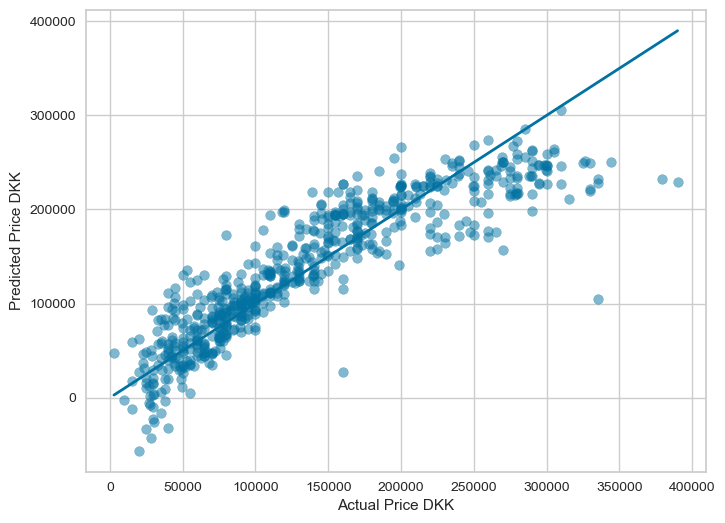

In [73]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predicted, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], lw=2)
plt.xlabel('Actual Price DKK')
plt.ylabel('Predicted Price DKK')
plt.show()

In [74]:
#Test of the ML-algo with the known values of one car
data = [[117000, 11, 1200, 18.5]]

cols = ['odometer', 'age', 'ccm2', 'km/l']
df_input = pd.DataFrame(data, columns=cols)

# Scale the input values
car_1692_scaled = scaler.transform(df_input)

price_predicted = myreg.predict(car_1692_scaled)
print(f"Price predicted: {price_predicted}")
# True price is 64 880

Price predicted: [108790.02157754]


### Evaluating the Model

#### MAE

In [75]:
# Mean Absolute Error (MAE) is the mean of the absolute value of the errors:
mae = metrics.mean_absolute_error(y_test, y_predicted)
print(mae)

26412.328592758327


On average, the models price prediction is off by ca 26 000 DKK.

#### MSE and RMSE

In [76]:
# Mean Squared Error (MSE) is the mean of the squared errors:
mse = metrics.mean_squared_error(y_test, y_predicted)
print(mse)

1325609475.906117


In [77]:
# Root Mean Squared Error (RMSE) is the square root of the mean of the squared errors:
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_predicted))
print(rmse)

36408.92027932327


The larger RMSE indicates some outliers skewing the RMSE

#### Accuracy (r2)

In [78]:
r2 = metrics.r2_score(y_test, y_predicted)
print(r2)

0.8020809786176426


80 % of the cars price can be predicted by the four attributes: age, km/l, ccm2, odometer.

### Saving the Model

In [79]:
filename = 'car_linear_model.pkl'
joblib.dump(myreg, filename)

['car_linear_model.pkl']

## Unsupervised machine learning for clustering

### Choosing the number of clusters

In [80]:
# Elbow method
K = range(2,10)
distortions = []
for k in K:
    model = KMeans(n_clusters=k, n_init=10)
    model.fit(X)
    dist = sum(np.min(cdist(X, model.cluster_centers_, 'euclidean'), axis=1)) / X.shape[0]
    distortions.append(dist) 
    
# print all distortions to identify the lowest gain
print("Distortion: ", distortions)

Distortion:  [np.float64(0.26713860829278335), np.float64(0.21846537296657093), np.float64(0.19063283515414753), np.float64(0.17504470176820916), np.float64(0.1669986715762598), np.float64(0.15771399473415867), np.float64(0.14644492908746767), np.float64(0.14029483256125336)]


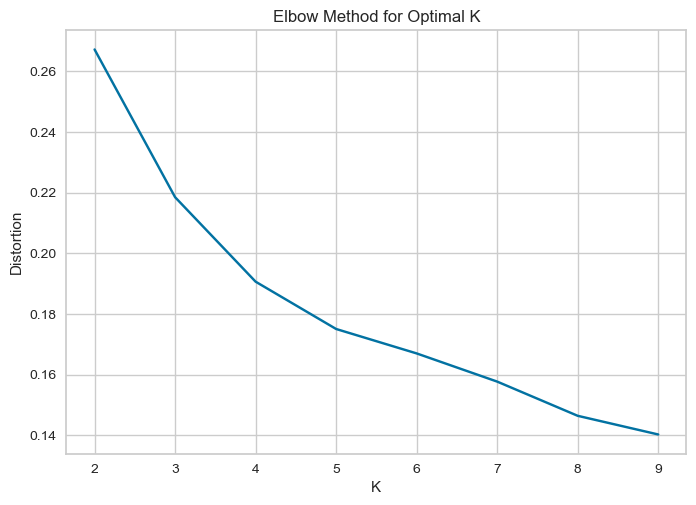

In [81]:
# Plot the distortion to discover the elbow to determine the optimal number of clusters
plt.title('Elbow Method for Optimal K')
plt.plot(K, distortions, 'bx-')
plt.xlabel('K')
plt.ylabel('Distortion')
plt.show()

The elbow methods suggest that we use 4 clusters

In [82]:
# Determine k by maximising the silhouette score for each number of clusters
scores = []
K = range(2,10)
for k in K:
    model = KMeans(n_clusters=k, n_init=10)
    model.fit(X)
    score = metrics.silhouette_score(X, model.labels_, metric='euclidean', sample_size=len(X))
    print("\nNumber of clusters =", k, "\tSilhouette score =", score)
    scores.append(score)


Number of clusters = 2 	Silhouette score = 0.4080378989129183

Number of clusters = 3 	Silhouette score = 0.36592028525569475

Number of clusters = 4 	Silhouette score = 0.38197634230094124

Number of clusters = 5 	Silhouette score = 0.35069923261238256

Number of clusters = 6 	Silhouette score = 0.32337154917186467

Number of clusters = 7 	Silhouette score = 0.33034121942775285

Number of clusters = 8 	Silhouette score = 0.3326439530854011

Number of clusters = 9 	Silhouette score = 0.3296755115690807


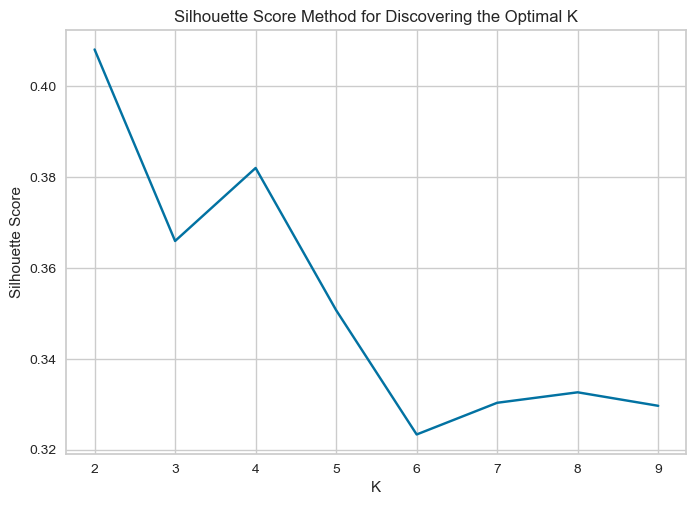

In [83]:
# Plot the elbow
plt.title('Silhouette Score Method for Discovering the Optimal K')
plt.plot(K, scores, 'bx-')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

The silhouette methods suggest that we use 2 clusters or secondly 4 clusters (as the elbow method also suggest), which we will do to get a more interesting segmentation

### Making the model

In [84]:
# Optimal number of clusters
num_clusters = 4

In [85]:
# KInstance of KMeans classifier
kmeans = KMeans(init = 'k-means++', n_clusters=num_clusters, n_init=20)

In [86]:
# Train the KMeans clustering model
kmeans.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


### Testing the Model

In [87]:
# Predict 4 clusters in X
predicted = kmeans.predict(X)
predicted

array([1, 3, 3, ..., 3, 3, 3], shape=(2546,), dtype=int32)

In [88]:
# Append the cluster label to each car in a new column
df_cluster = pd.DataFrame(X)
df_cluster['label'] = kmeans.labels_

In [89]:
# Check the new cluster column
df_cluster

,0,1,2,3,label
0,0.166667,0.657277,0.113636,0.060606,1
1,0.611111,0.600939,0.045455,0.855219,3
2,1.000000,0.295775,0.181818,0.828283,3
3,0.277778,0.483568,0.227273,0.326599,0
4,0.555556,0.436620,0.136364,0.468013,0
...,...,...,...,...,...
2541,0.500000,0.563380,0.000000,0.791246,2
2542,0.555556,0.737089,0.000000,0.622896,2
2543,0.888889,0.154930,0.318182,0.996633,3
2544,0.833333,0.112676,0.681818,0.488215,3


Given that we have 4 variables we will make different 2 dimensional plots to see the clusters

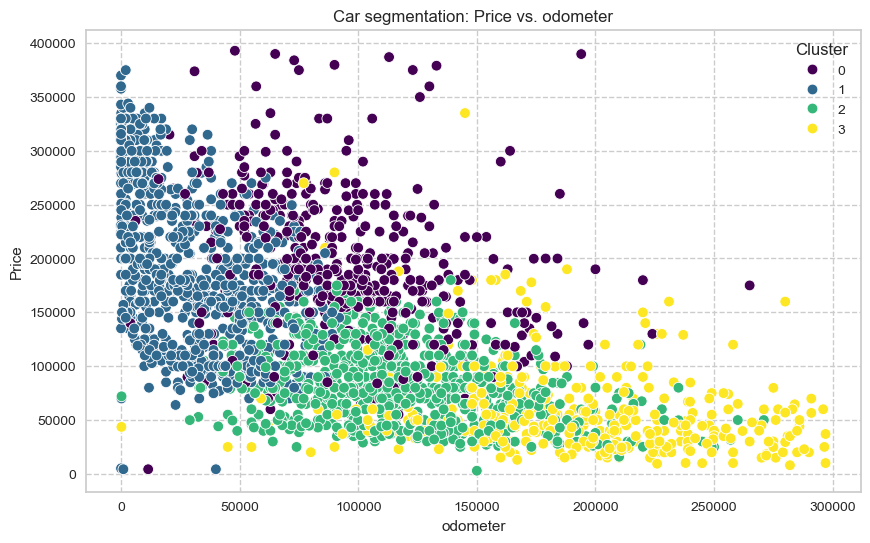

In [90]:
plt.figure(figsize=(10, 6))
sbn.scatterplot(data=df_without_outliers, x='odometer', y='price', 
                hue=predicted, palette='viridis', s=60)

plt.title('Car segmentation: Price vs. odometer')
plt.xlabel('odometer')
plt.ylabel('Price')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--')
plt.show()

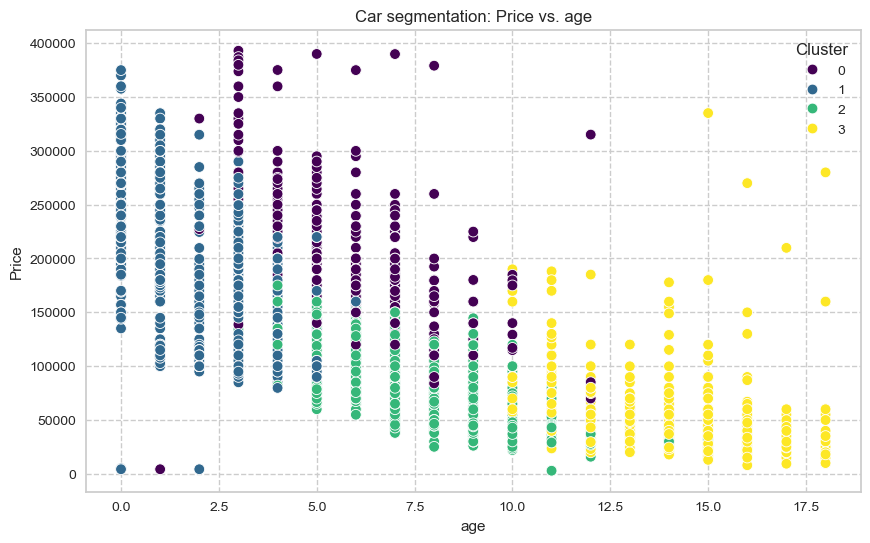

In [91]:
plt.figure(figsize=(10, 6))
sbn.scatterplot(data=df_without_outliers, x='age', y='price', 
                hue=predicted, palette='viridis', s=60)

plt.title('Car segmentation: Price vs. age')
plt.xlabel('age')
plt.ylabel('Price')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--')
plt.show()

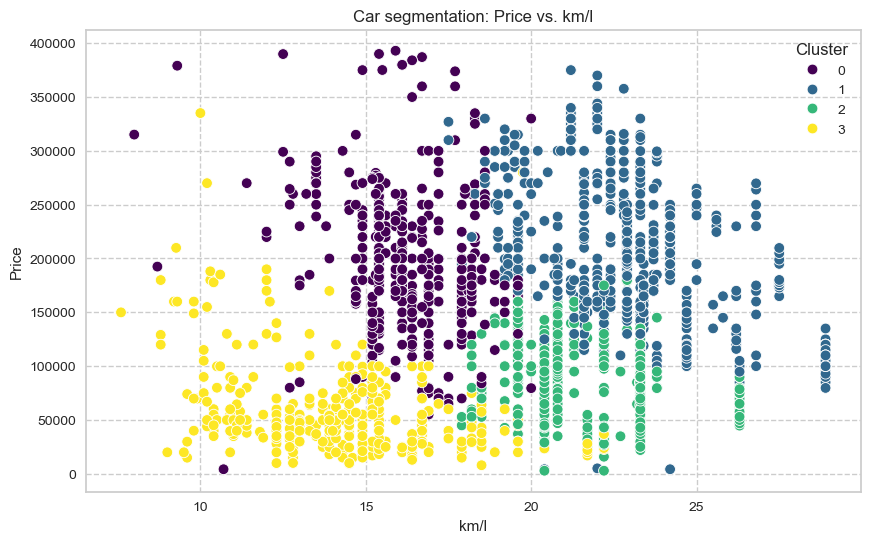

In [92]:
plt.figure(figsize=(10, 6))
sbn.scatterplot(data=df_without_outliers, x='km/l', y='price', 
                hue=predicted, palette='viridis', s=60)

plt.title('Car segmentation: Price vs. km/l')
plt.xlabel('km/l')
plt.ylabel('Price')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--')
plt.show()

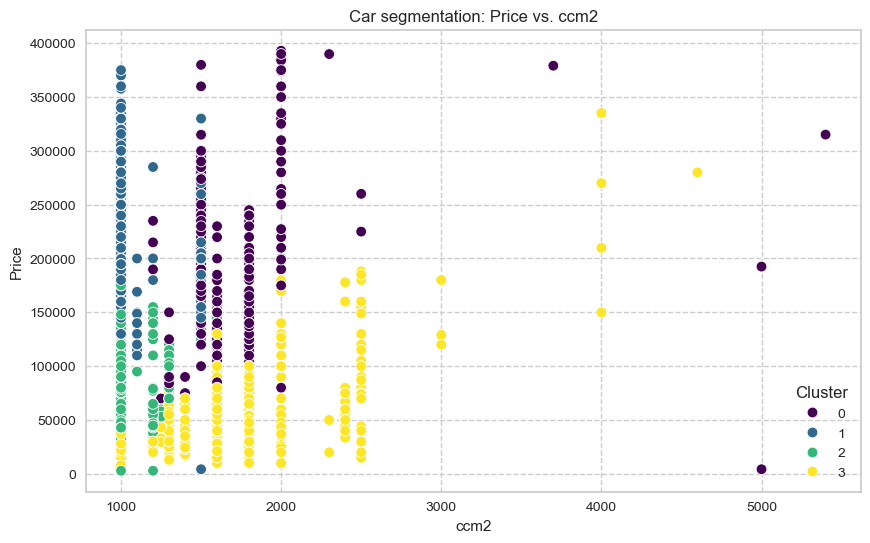

In [93]:
plt.figure(figsize=(10, 6))
sbn.scatterplot(data=df_without_outliers, x='ccm2', y='price', 
                hue=predicted, palette='viridis', s=60)

plt.title('Car segmentation: Price vs. ccm2')
plt.xlabel('ccm2')
plt.ylabel('Price')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--')
plt.show()

### Evaluating the Model

In [94]:
k = 4
model = KMeans(n_clusters=k, n_init=10)
model.fit_predict(X)

array([2, 1, 1, ..., 1, 1, 1], shape=(2546,), dtype=int32)

In [95]:
score = silhouette_score(X, model.labels_, metric='euclidean')
print('Silhouette Score: %.3f' % score)

Silhouette Score: 0.382


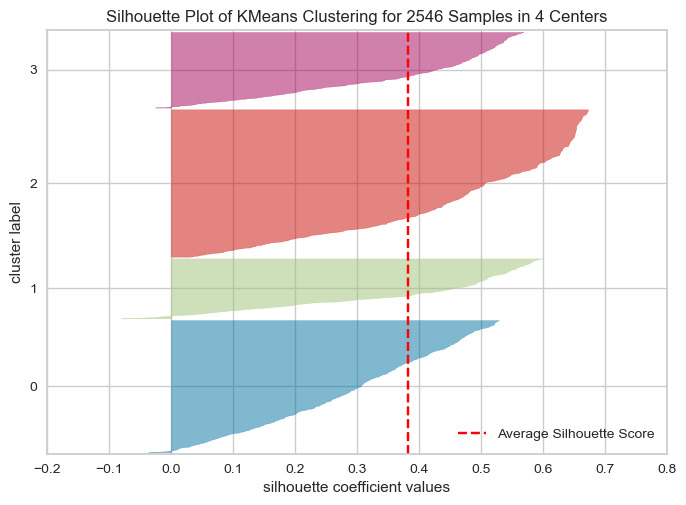

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2546 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [96]:
# Visualize the silhouette scores of all points
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(X)
visualizer.show() 

In [116]:
# Testing the model
test_car = pd.DataFrame([[5, 20, 1200, 80000]], columns=['age', 'km/l', 'ccm2', 'odometer'])

prediction = kmeans.predict(test_car)

print(f"Car belongs to cluster: {prediction[0]}")

Car belongs to: 3


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


### Saving the Model

In [117]:
filename = 'kmeans_model.pkl'
joblib.dump(kmeans, filename)

['kmeans_model.pkl']

## Supervised machine learning for classification

### Making the Model

Preparing the data:

In [98]:
# Price segments
bins = [0, 60000, 120000, 250000, np.inf]
labels = ['Budget', 'Low', 'Medium', 'Expensive']

df_scaled['price_segment'] = pd.cut(df_scaled['price'], bins = bins, labels = labels)

print(df_scaled['price_segment'].value_counts())

price_segment
Medium       980
Low          774
Budget       500
Expensive    292
Name: count, dtype: int64


Splitting the data:

In [99]:
# Split the dataset into into training and testing sets in proportion 75:25

prop = 0.25
seed = 123

X = df_scaled[['age', 'km/l', 'ccm2', 'odometer']]
y = df_scaled['price_segment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=prop, random_state=seed)

Traing the Model:


In [100]:
# Choosing the depth of the tree
params = {'max_depth': None}

In [101]:
# Making Deci
classifier = DecisionTreeClassifier(**params)

In [102]:
classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


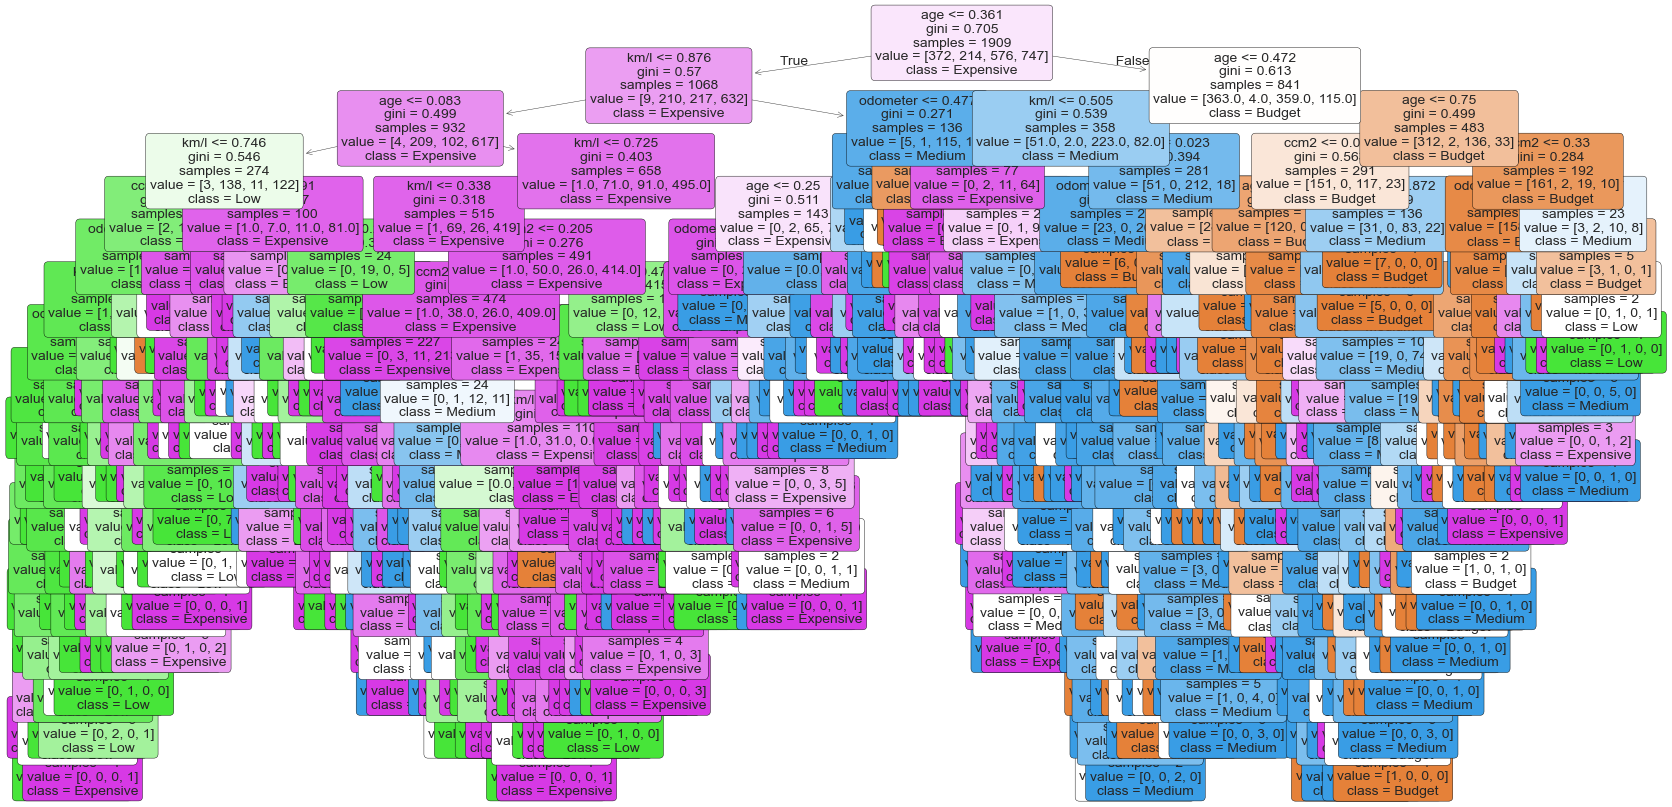

In [103]:
# Visualising the decision tree. To get at better view try reduceing the depth of the tree
plt.figure(figsize=(20,10))

tree.plot_tree(classifier, 
               feature_names=X.columns, 
               class_names=labels, 
               filled=True, 
               rounded=True, 
               fontsize=10)

plt.show()

### Testing the Model

In [104]:
# The predicted values
y_test_predicted = classifier.predict(X_test)

print(y_test_predicted)

['Budget' 'Medium' 'Medium' 'Expensive' 'Low' 'Medium' 'Medium' 'Low'
 'Expensive' 'Medium' 'Medium' 'Medium' 'Budget' 'Low' 'Budget'
 'Expensive' 'Medium' 'Medium' 'Expensive' 'Budget' 'Medium' 'Budget'
 'Budget' 'Medium' 'Medium' 'Low' 'Medium' 'Medium' 'Medium' 'Expensive'
 'Low' 'Medium' 'Medium' 'Low' 'Medium' 'Budget' 'Low' 'Medium' 'Budget'
 'Low' 'Low' 'Low' 'Budget' 'Budget' 'Medium' 'Budget' 'Low' 'Medium'
 'Budget' 'Medium' 'Budget' 'Expensive' 'Low' 'Medium' 'Medium' 'Low'
 'Budget' 'Low' 'Low' 'Medium' 'Budget' 'Expensive' 'Low' 'Low' 'Medium'
 'Low' 'Medium' 'Budget' 'Expensive' 'Medium' 'Medium' 'Medium' 'Low'
 'Budget' 'Medium' 'Medium' 'Budget' 'Low' 'Medium' 'Medium' 'Budget'
 'Medium' 'Budget' 'Low' 'Low' 'Budget' 'Budget' 'Low' 'Budget'
 'Expensive' 'Expensive' 'Low' 'Low' 'Budget' 'Low' 'Low' 'Medium'
 'Budget' 'Budget' 'Medium' 'Medium' 'Low' 'Expensive' 'Expensive'
 'Medium' 'Medium' 'Expensive' 'Low' 'Medium' 'Budget' 'Budget' 'Budget'
 'Budget' 'Budget' 'Low' '

In [105]:
# The true values
y_test

1524       Budget
1707       Medium
2340       Medium
891     Expensive
2209       Medium
          ...    
299           Low
1249          Low
1917       Budget
1888       Medium
1430       Budget
Name: price_segment, Length: 637, dtype: category
Categories (4, str): ['Budget' < 'Low' < 'Medium' < 'Expensive']

### Evaluating the Model

In [106]:
# Predicted values vs actual values
print(pd.Series(y_test_predicted).value_counts())
print(pd.Series(y_test).value_counts())

Medium       233
Low          190
Budget       135
Expensive     79
Name: count, dtype: int64
price_segment
Medium       233
Low          198
Budget       128
Expensive     78
Name: count, dtype: int64


We can see that the model has been quite good at predicting the price segment of a car

#### Accuaracy_score method

In [165]:
# Comapring the predicted values with the actual values
accuracy = accuracy_score(y_test, y_test_predicted)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8351648351648352


##### We can see that in 83.5% of the cases the model is right.

#### Confusion Matrix

In [108]:
confusion_mat = confusion_matrix(y_test, y_test_predicted)
confusion_mat

array([[112,   0,  16,   0],
       [  0,  66,   1,  11],
       [ 22,   0, 154,  22],
       [  1,  13,  19, 200]])

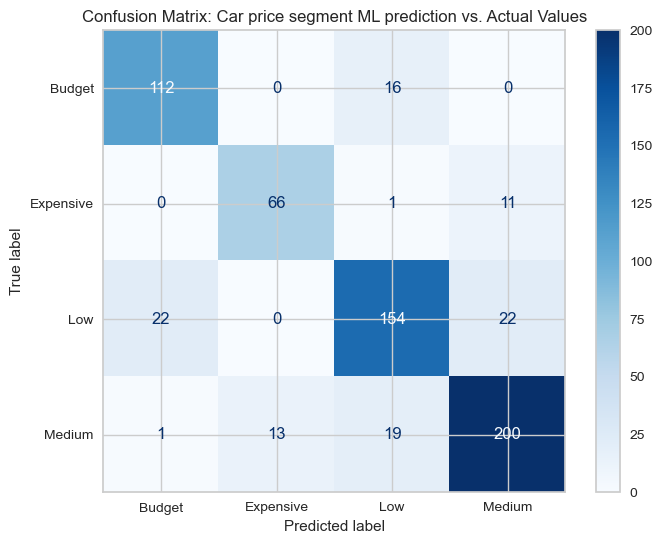

In [109]:
fig, ax = plt.subplots(figsize=(8, 6))
display = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=classifier.classes_)

display.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Car price segment ML prediction vs. Actual Values')
plt.show()

From the matrix we can see that when the model predicts wrong it is not far off. It's mostly only off by one segment. There is fx. 0 cases where it predicted expensive but the true result was low.

#### Classification Report

In [110]:
def report(x_set, y_set, class_names):

    predicted = classifier.predict(x_set)

    class_report = classification_report(y_set, predicted, target_names=class_names)

    score = accuracy_score(y_set, predicted)

    print('accuracy score = ', score)

    return class_report

In [111]:
labels = classifier.classes_

Traing data:

In [112]:
print(report(X_train, y_train, labels))

accuracy score =  0.9921424829753798
              precision    recall  f1-score   support

      Budget       0.99      1.00      0.99       372
   Expensive       0.96      1.00      0.98       214
         Low       1.00      0.99      1.00       576
      Medium       1.00      0.99      0.99       747

    accuracy                           0.99      1909
   macro avg       0.99      0.99      0.99      1909
weighted avg       0.99      0.99      0.99      1909



Test data:

In [113]:
print(report(X_test, y_test, labels))

accuracy score =  0.8351648351648352
              precision    recall  f1-score   support

      Budget       0.83      0.88      0.85       128
   Expensive       0.84      0.85      0.84        78
         Low       0.81      0.78      0.79       198
      Medium       0.86      0.86      0.86       233

    accuracy                           0.84       637
   macro avg       0.83      0.84      0.84       637
weighted avg       0.83      0.84      0.83       637



Comparing the two reports we can see that there is some overfitting (99.2 % vs 82.7%). 

The difference could be that there are other factors that determine the price of the car that we have not included in our model, ie. cosmetics, loans in the car, number of doors, etc.  

Or it could be that our chosen limits for the car price segments should be reconsidered.

#### K-Fold Cross-Validation
To run the model with different datasets and validate its accuracy

In [114]:
k_folds = KFold(n_splits=5)
scores = cross_val_score(classifier, X, y, cv= k_folds)

print("Results for each k-fold:", scores)
print("Mean of k-folds:", scores.mean())

Results for each k-fold: [0.84117647 0.8388998  0.82514735 0.84282908 0.80746562]
Mean of k-folds: 0.8311036634693171


Running the data shows that there is a high degree of consistency and the mean of the folds (83.1%) are very close to the 84.5% we have found in our model

### Saving the Model

In [115]:
filename = 'car_classification_model.pkl'
joblib.dump(classifier, filename)

['car_classification_model.pkl']